<a href="https://colab.research.google.com/github/miriamamin1213-ux/FinalModels/blob/main/RF_Hecktor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading...
From: https://drive.google.com/uc?id=1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv
To: /content/HPV2025.xlsx
100%|██████████| 66.0k/66.0k [00:00<00:00, 46.3MB/s]
/tmp/ipykernel_1011/96101011.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["T-stage"]=df["T-stage"].replace({"T0":0,"T1":1,"T2":2,"T3":3,"T4":4})
/tmp/ipykernel_1011/96101011.py:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["N-stage"]=df["N-stage"].replace({"N0":0,"N1":1,"N2":2,"N3":3})
/tmp/ipykernel_1011/96101011.py:42: FutureWarning: Downcasting beh

Dataset Shape: (588, 12)

Class Distribution
HPV Status
1.0    530
0.0     58
Name: count, dtype: int64

Train samples:
HPV Status
1.0    424
0.0     46
Name: count, dtype: int64

Test samples:
HPV Status
1.0    106
0.0     12
Name: count, dtype: int64

Number of Features: 11

Training class distribution - No SMOTE:
HPV Status
1.0    424
0.0     46
Name: count, dtype: int64

Classification Report

              precision    recall  f1-score   support

         0.0     0.7500    0.2500    0.3750        12
         1.0     0.9211    0.9906    0.9545       106

    accuracy                         0.9153       118
   macro avg     0.8355    0.6203    0.6648       118
weighted avg     0.9037    0.9153    0.8956       118

Confusion Matrix
[[  3   9]
 [  1 105]]

Accuracy:            0.9153
Balanced Accuracy:   0.6203
F1-score:            0.9545
AUC:                 0.7677

RANDOM FOREST42_HECKTOR SUMMARY
Model : Random Forest
Input Features : 11
Learning Rate : N/A
Optimiser : N/A
Class We

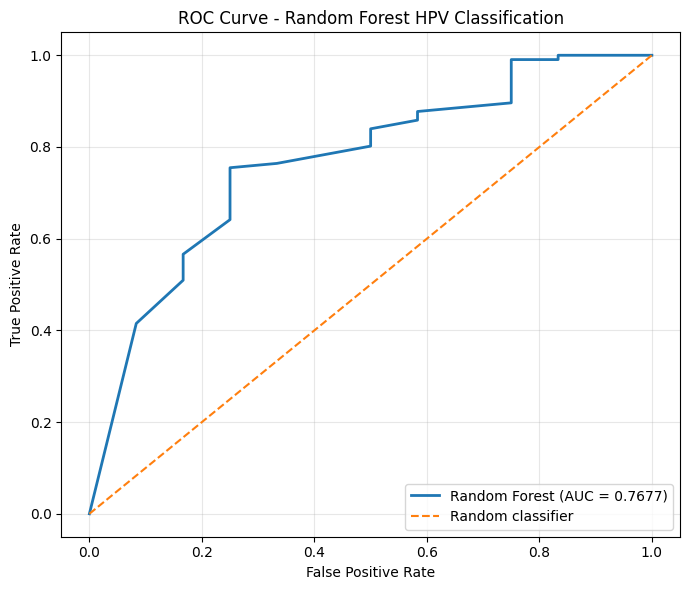

ROC AUC: 0.7677


In [1]:
# ============================================================
# RANDOM FOREST_42_Hecktor - NO SMOTE
# ============================================================

!pip install -q gdown
import gdown
gdown.download(id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv",output="HPV2025.xlsx",quiet=False)

import os,random,numpy as np,pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,balanced_accuracy_score,roc_auc_score,f1_score,roc_curve
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"]=str(seed)

SEED=42
seed_everything(SEED)

# ------------------------------------------------------------
# Read Dataset
# ------------------------------------------------------------

df=pd.read_excel("HPV2025.xlsx")
df=df.dropna(subset=["HPV Status"]).copy()
df=df.drop(columns=["PatientID","CenterID","Task 1","Task 2","Task 3"])

# ------------------------------------------------------------
# Encode stages
# ------------------------------------------------------------

df["T-stage"]=df["T-stage"].replace({"T0":0,"T1":1,"T2":2,"T3":3,"T4":4})
df["N-stage"]=df["N-stage"].replace({"N0":0,"N1":1,"N2":2,"N3":3})
df["M-stage"]=df["M-stage"].replace({"M0":0,"M1":1})

# ------------------------------------------------------------
# Features
# ------------------------------------------------------------

feature_cols=["Age","Gender","Tobacco Consumption","Alcohol Consumption","Performance Status","Relapse","RFS","Treatment","T-stage","N-stage","M-stage"]
X=df[feature_cols].copy()
y=df["HPV Status"].copy()

print("Dataset Shape:",df.shape)
print("\nClass Distribution")
print(y.value_counts())

# ------------------------------------------------------------
# Split
# Stratified by HPV Status
# ------------------------------------------------------------

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,random_state=SEED,stratify=y
)
X_train=X_train.copy()
X_test=X_test.copy()

print("\nTrain samples:")
print(y_train.value_counts())
print("\nTest samples:")
print(y_test.value_counts())

# ------------------------------------------------------------
# Missing Values
# Train-derived values ONLY
# ------------------------------------------------------------

cat_cols=["Gender","Tobacco Consumption","Alcohol Consumption","Performance Status","Relapse","Treatment","T-stage","N-stage","M-stage"]
num_cols=["Age","RFS"]

for col in cat_cols:
    value=X_train[col].mode()[0]
    X_train[col]=X_train[col].fillna(value)
    X_test[col]=X_test[col].fillna(value)

for col in num_cols:
    value=X_train[col].median()
    X_train[col]=X_train[col].fillna(value)
    X_test[col]=X_test[col].fillna(value)

# ------------------------------------------------------------
# Encoding
# Train-only encoding
# ------------------------------------------------------------

encoder=OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1)
X_train[cat_cols]=encoder.fit_transform(X_train[cat_cols].astype(str))
X_test[cat_cols]=encoder.transform(X_test[cat_cols].astype(str))

# ------------------------------------------------------------
# Standardisation
# ------------------------------------------------------------

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

print("\nNumber of Features:",X.shape[1])

# ------------------------------------------------------------
# NO SMOTE
# ------------------------------------------------------------

print("\nTraining class distribution - No SMOTE:")
print(y_train.value_counts())

# ------------------------------------------------------------
# Random Forest Model
# ------------------------------------------------------------

class_counts=np.bincount(y_train)
class_weights=len(y_train)/(len(class_counts)*class_counts)
class_weight_dict={i:class_weights[i] for i in range(len(class_weights))}

model=RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weight_dict,
    random_state=SEED
)
model.fit(X_train,y_train)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

predicted=model.predict(X_test)
probabilities=model.predict_proba(X_test)[:,1]

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print()
print("Classification Report\n")
print(classification_report(y_test,predicted,digits=4))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm=confusion_matrix(y_test,predicted)
print("Confusion Matrix")
print(cm)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy=(predicted==y_test).sum()/len(y_test)
bal_acc=balanced_accuracy_score(y_test,predicted)
f1=f1_score(y_test,predicted)
auc=roc_auc_score(y_test,probabilities)

print()
print(f"Accuracy:            {accuracy:.4f}")
print(f"Balanced Accuracy:   {bal_acc:.4f}")
print(f"F1-score:            {f1:.4f}")
print(f"AUC:                 {auc:.4f}")

# ------------------------------------------------------------
# MODEL SUMMARY
# ------------------------------------------------------------

print()
print("====================================")
print("RANDOM FOREST42_HECKTOR SUMMARY")
print("====================================")
print("Model : Random Forest")
print("Input Features : 11")
print("Learning Rate : N/A")
print("Optimiser : N/A")
print("Class Weights : Automatic (np.bincount)")
print("SMOTE : No")
print("Preprocessing : Train-only")
print("Imputation : Train-derived mode/median")
print("Encoding : Train-fitted OrdinalEncoder")
print("Scaling : Train-fitted StandardScaler")
print("n_estimators :",100)
print("Training Patients :",len(y_train))
print("Test Patients :",len(y_test))
print("Seed :",SEED)
print()
print("Final Results")
print("---------------------------")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Balanced Accuracy   : {bal_acc:.4f}")
print(f"F1-score            : {f1:.4f}")
print(f"AUC                 : {auc:.4f}")
print()
print("Confusion Matrix")
print(cm)
print()
print("Analysis Complete.")

# ------------------------------------------------------------
# ROC / AUC CURVE
# ------------------------------------------------------------

fpr,tpr,thresholds=roc_curve(y_test,probabilities)
auc_curve=roc_auc_score(y_test,probabilities)

plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,linewidth=2,label=f'Random Forest (AUC = {auc_curve:.4f})')
plt.plot([0,1],[0,1],linestyle='--',linewidth=1.5,label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest HPV Classification')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {auc_curve:.4f}")